In [104]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Hypothesis testing: Chi-Square Test



Source: "Practical Statistics for Data Scientists" (124 - 126).

In this notebook we'll show you how to calculate a chi-square test. We'll do this twice.
* First, we'll go through the approach manually so you can see the maths and reasoning behind what we're doing - this should help with comprehension and help you to design better experiments.
* Second, we'll go through the shorter coding way, where a computer will do all the work for you, but won't tell you why, it's a black box of numbers.

# I. The manual approach

Imagine we made three different versions of a website and each version received 1000 visits last week. On each website, we placed a button with a slightly different appearance, but all leading to the same super cool thing. Now we want to find out if one of the versions is significantly better than the others.

In order to determine if one of the website versions is significantly better than the others, we can use the chi-squared test. This test helps us understand whether any observed differences in the number of button clicks are statistically significant or not.

The chi-squared test compares the observed frequencies, which are the actual number of clicks for each website version, with the expected frequencies, which are the number of clicks we would expect if all versions were equally effective. By analyzing the difference between the observed and expected frequencies, the chi-squared test calculates a statistical value called the chi-squared statistic (similar to the t-score, a.k.a the t-statistic).

If the chi-squared statistic is large enough and exceeds a certain critical value, we can conclude that the differences in button clicks are unlikely to occur by chance alone.


## 1.&nbsp; State the Null Hypothesis and the Alternative Hypothesis.

**Null Hypothesis ($H_0$):** The click rate on each website (A, B, and C) is equal.

**Alternative Hypothesis ($H_A$):** At least one of the websites has a significantly different click rate compared to the others, either better or worse.

## 2.&nbsp; Select an appropriate significance level alpha ($\alpha$).

When choosing a significance level ($\alpha$), we are choosing our tolerance for False Positives (Type I errors). Typical values for alpha are 0.1, 0.05, or 0.01.

If we choose a low alpha, we demand high certainty. This is great for avoiding False Positives, meaning we are less likely to implement a change that does not actually offer an improvement, but it makes the test less sensitive. We might commit a Type II error (False Negative), failing to adopt a version that actually performs better because the evidence didn't quite reach that high confidence threshold.

For our case, we'll go with $\alpha = 0.1$. This 'loosens' the requirements compared to smaller values. While it increases our risk of a false positive, it also significantly increases the test's **Statistical Power**, making it more likely to detect smaller, real improvements in the website's performance.

In [105]:
alpha = 0.1

## 3.&nbsp; Collect Data that is random and independent

We will assume that this experiment was carefully designed, ensuring that the data collected is random and independent, which is crucial for reliable statistical analysis.

To recap, we created three distinct versions of a website, and each version received 1000 visits last week. On each website, we implemented a button with a slightly different appearance that directed users to the same super cool thing. Below are the results, showing the number of people who clicked on the button, and didn't click on the button, for each website version.

In [106]:
Click = [14, 8, 12]
No_click = [986, 992, 988]

observed_results = pd.DataFrame(
    [Click, No_click], columns=["A", "B", "C"], index=["Click", "No-click"]
)
observed_results

,A,B,C
Click,14,8,12
No-click,986,992,988


## 4.&nbsp; Calculate the test result
The Chi-squared statistic is calculated by:

\begin{align}
\chi^2_c = \sum_{\substack{0\le i\le r\\0\le j\le n}}\frac{(O_{ij}-E_{ij})^2} {E_{ij}}
    \end{align}

where
<center>
r = total number of rows

n = total number of columns

c = degrees of freedom

$O_{ij}$ = observed value in the ith row and jth column

$E_{ij}$ = expected value in the ith row and jth column
</center>

---

While this formula may seem daunting at first glance, it's not as complex as it appears. To calculate the Chi-Squared statistic, you perform the following steps for each cell in the table: subtract the expected value from the observed value, square the result, and then divide this value by the expected value. This process is repeated for each cell in the table, and the individual results are then summed up to yield the Chi-Squared statistic.

### Calculating degrees of freedom
The formula for calculating the degrees of freedom is:
\begin{align}
dof = (r - 1) \times (n - 1)
    \end{align}
where
<center>
r = total number of rows<br>   
n = total number of columns
</center>

In [107]:
r = observed_results.shape[0]
r

2

In [108]:
n = observed_results.shape[1]
n

3

In [109]:
dof = (r - 1) * (n - 1)
dof

2

Let's plot a few chi squared distributions with different degrees of freedom to see how they differ from t-distributions.

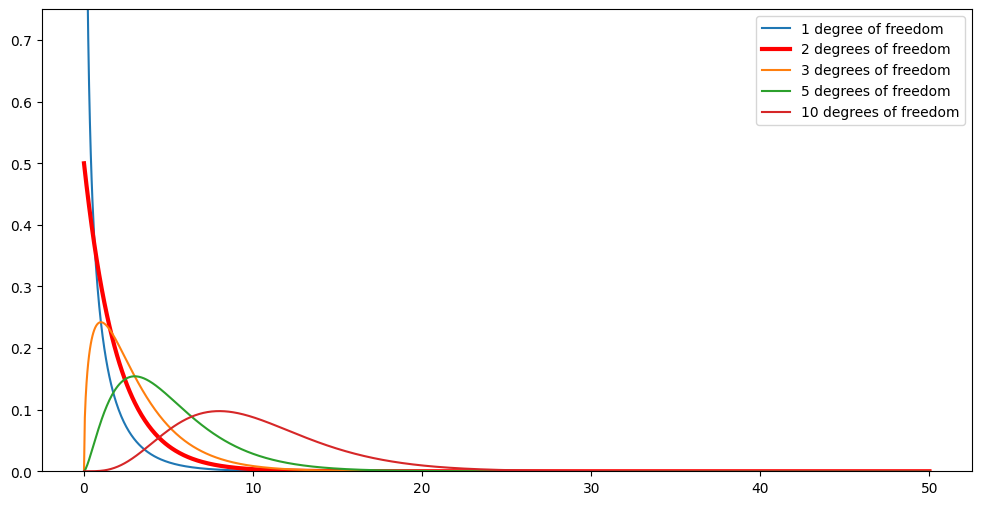

In [110]:
"""
We intentionally placed this code within a form to ensure you stayed focused
on the main topic. However, if you’re interested in exploring Matplotlib further,
you can ask ChatGPT to explain the code line by line, ensuring you understand
everything being used here. There are also plenty of free courses and YouTube
videos available on Matplotlib.

Our suggestion, though, is not to attempt to learn everything about Matplotlib
in one go — you’ll likely forget most of it and end up googling for answers like
the rest of us. Instead, adopt a curious mindset. When you encounter Matplotlib
code, take the time to examine and understand it, but don’t linger. Over time,
this approach helps you gradually discover what’s possible with Matplotlib and
develop your intuition.
"""

# @title Chi-squared distributions with different degrees of freedom

import numpy as np
from scipy.stats import chi2

plt.figure(figsize=(12, 6))
# Create a linear space from 0 to 50 with 1000 intervals for our x-axis.
xt = np.linspace(0, 50, 1000)
# Show values on the y-axis between 0 and 0.75.
plt.ylim(0, 0.75)
# Plot chi-squared distributions with different degrees of freedom.
plt.plot(xt, chi2.pdf(xt, 1), label="1 degree of freedom")
plt.plot(xt, chi2.pdf(xt, 2), color="red", lw=3, label="2 degrees of freedom")
plt.plot(xt, chi2.pdf(xt, 3), label="3 degrees of freedom")
plt.plot(xt, chi2.pdf(xt, 5), label="5 degrees of freedom")
plt.plot(xt, chi2.pdf(xt, 10), label="10 degrees of freedom")
plt.legend()
plt.show()

### Calculating the expected value for each cell

\begin{align}
E_{ij} = expected\ value\ in\ the\ ith\ row\ and\ jth\ column
    \end{align}

Here, i and j represent integers that indicate the coordinates of a value within the DataFrame. The expected value represents what each value would have been in a theoretical world where there is absolutely no difference in the influence of the different buttons, i.e. the CTR is the same for every version


To calculate the expected value ($E_{ij}$) for a cell in a chi-squared test, multiply the proportion of the participants in each column by the total observances in each row. In our example, `1000/3000` people saw `version "A"`. We would then expect that $\frac{1}{3}$ of _all_ "Click" actions (34 in total) and $\frac{1}{3}$ of _all_ "No Click" actions (2966 in total) would be found in column `"A"`. In effect, you can use the formula:


\begin{align}
E_{ij} = \frac{(Total\ in\ Column\ j)}{Grand\ Total} \times(Total\ in\ Row\ i)
    \end{align}

---

$E_{ij}$ is the expected value for the cell at the intersection of row $i$ and column $j$.

"Total in Row $i$" is the sum of all values in Row $i$.

"Total in Column $j$" is the sum of all values in Column $j$.

"Grand Total" is the sum of all values in the entire contingency table.

---


In [111]:
# Calculate row totals - stored as a vertical DataFrame
row_totals = observed_results.sum(axis=1).to_frame()

# Calculate column totals - stored as a horizontal DataFrame
column_totals = observed_results.sum(axis=0).to_frame().T

# Calculate the grand total - a single value
grand_total = observed_results.values.sum()

# Calculate the population proportions
proportions = column_totals/grand_total

# Multiply proportions by row totals to get expected values
expected_results = row_totals.dot(proportions)

expected_results

,A,B,C
Click,11.333333,11.333333,11.333333
No-click,988.666667,988.666667,988.666667


### Calculating the Chi-squared statistic

Remember, our formula is:

\begin{align}
\sum_{\substack{0\le i\le r\\0\le j\le n}}\frac{(O_{ij}-E_{ij})^2} {E_{ij}}
    \end{align}

Which means that for each cell of the contingent table, we want to minus the expected value from the observed value, square this number, and then divide it by the expected value. By adding together this result for each cell, we get the chi squared statistic.

The great news is, since `observed_results` and `expected_results` have the same labels we can directly subtract and divide cell-by-cell.

In [112]:
chi_squared = (
    ((observed_results - expected_results) ** 2 / expected_results)
    .sum() # add up the columns
    .sum() # add column sums together
)
chi_squared

np.float64(1.6659394708658921)

Let's see where the chi-squared test statistic is in the plot of the chi-squared distribution.

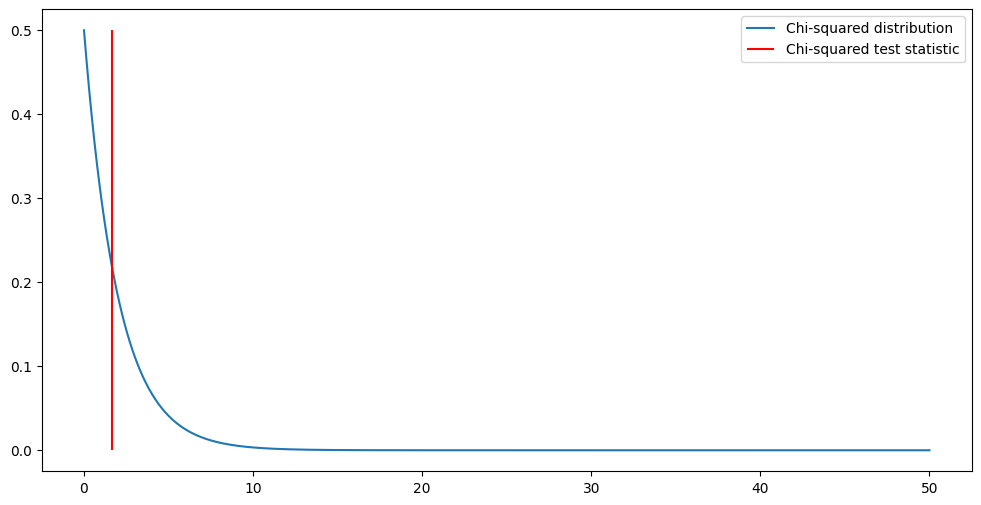

In [113]:
"""
We intentionally placed this code within a form to ensure you stayed focused
on the main topic. However, if you’re interested in exploring Matplotlib further,
you can ask ChatGPT to explain the code line by line, ensuring you understand
everything being used here. There are also plenty of free courses and YouTube
videos available on Matplotlib.

Our suggestion, though, is not to attempt to learn everything about Matplotlib
in one go — you’ll likely forget most of it and end up googling for answers like
the rest of us. Instead, adopt a curious mindset. When you encounter Matplotlib
code, take the time to examine and understand it, but don’t linger. Over time,
this approach helps you gradually discover what’s possible with Matplotlib and
develop your intuition.
"""

# @title Chi-squared distribution and test statistic
plt.figure(figsize=(12, 6))
# Create a linear space from 0 to 50 with 1000 intervals for our x-axis.
xt = np.linspace(0, 50, 1000)
# Plot a chi-squared distribution with the degrees of freedom from our sample.
plt.plot(xt, chi2.pdf(xt, dof), label="Chi-squared distribution")
# Add a vertical line for the chi-squared test statistic.
plt.vlines(
    chi_squared,
    ymin=0,
    ymax=max(chi2.pdf(xt, dof)),
    color="red",
    label="Chi-squared test statistic",
)
plt.legend()
plt.show()

## 5.&nbsp; Interpret the test result

Not too long ago, people used large tables to look up the critical values associated with a certain level of alpha, such as the one for the chi-squared test statistic below from [here](https://www.statology.org/how-to-read-chi-square-distribution-table/).

In the columns at the top, you need to select the level of alpha. In our case, alpha is 0.1.

Then you select the degrees of freedom of the test statistic's distribution in the first row. For any distribution with a different degree of freedom than the ones listed, the critical value will only be an approximation. In our case, the degrees of freedom is 2.

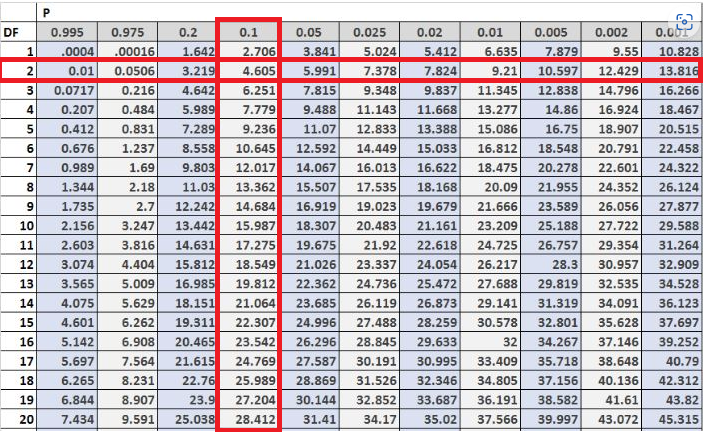

In [114]:
critical_value = 4.605

Let's remind ourselves of the chi-squared statistic

In [115]:
chi_squared

np.float64(1.6659394708658921)

Does this mean that we accept or reject the null hypothesis?

Let's visualise the chi-squared distribution with our test statistic and the critical value to make more sense of these numbers.

We include the critical value and identify the critical value.

Observe that the blue shaded area beneath the distribution curve encompasses all x-axis values that are more extreme than our critical value. This area represents alpha and corresponds to approximately 10% of the total area under the curve.

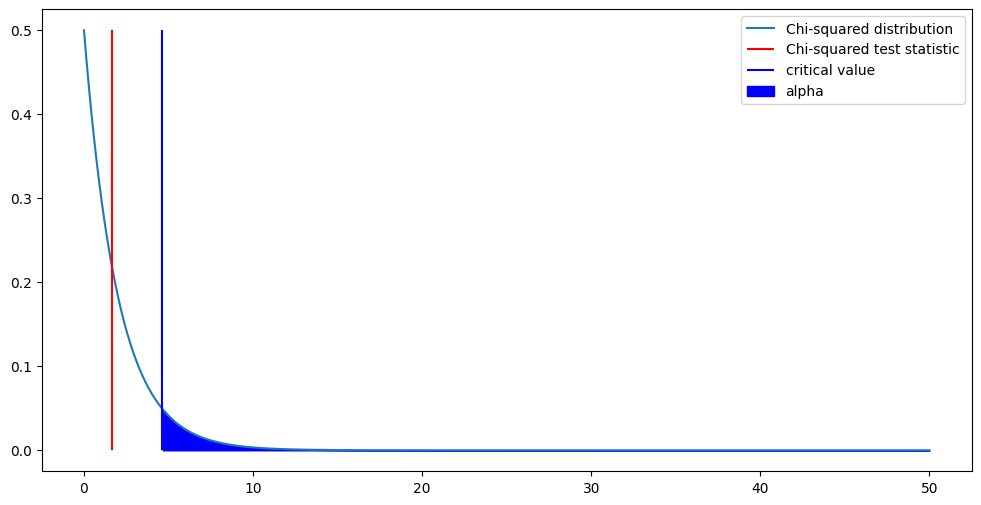

In [116]:
"""
We intentionally placed this code within a form to ensure you stayed focused
on the main topic. However, if you’re interested in exploring Matplotlib further,
you can ask ChatGPT to explain the code line by line, ensuring you understand
everything being used here. There are also plenty of free courses and YouTube
videos available on Matplotlib.

Our suggestion, though, is not to attempt to learn everything about Matplotlib
in one go — you’ll likely forget most of it and end up googling for answers like
the rest of us. Instead, adopt a curious mindset. When you encounter Matplotlib
code, take the time to examine and understand it, but don’t linger. Over time,
this approach helps you gradually discover what’s possible with Matplotlib and
develop your intuition.
"""

# @title Chi-squared distribution, test statistic and critical region
plt.figure(figsize=(12, 6))
# Plot a chi-squared distribution with the degrees of freedom from our sample.
plt.plot(xt, chi2.pdf(xt, dof), label="Chi-squared distribution")
# Add a vertical line for the chi-squared test statistic.
plt.vlines(
    chi_squared,
    ymin=0,
    ymax=max(chi2.pdf(xt, dof)),
    color="red",
    label="Chi-squared test statistic",
)
# Add vertical line for the critical value.
plt.vlines(
    critical_value,
    ymin=0,
    ymax=max(chi2.pdf(xt, dof)),
    color="blue",
    label="critical value",
)
# Shade the area under the curve for values more extreme than the critical value (= alpha).
plt.fill_between(
    xt, chi2.pdf(xt, dof), where=(xt > critical_value), color="b", label="alpha"
)
plt.legend()
plt.show()

The test statistic does not fall after the critical value as it is not more extreme than the critical value.

Therefore, we do not reject the Null Hypothesis.

Based on this analysis, we cannot conclude that any of the three different versions of the website performed significantly better or worse than the others. In fact, it is highly probable that they are perceived as nearly identical by the website visitors.

# II.&nbsp;The coder's approach

The faster way is to use [scipy's function](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.chi2_contingency.html) to perform chi-squared tests.

To determine whether or not to reject the Null Hypothesis, it is common to compare the alpha to the so-called p-value (instead of comparing the test statistic to the critical region).

> **Note**: Whether you compare alpha to the p-value or the test statistic to the critical value is a matter of personal taste. The result itself will always be the same.

You can see this in the chart below:

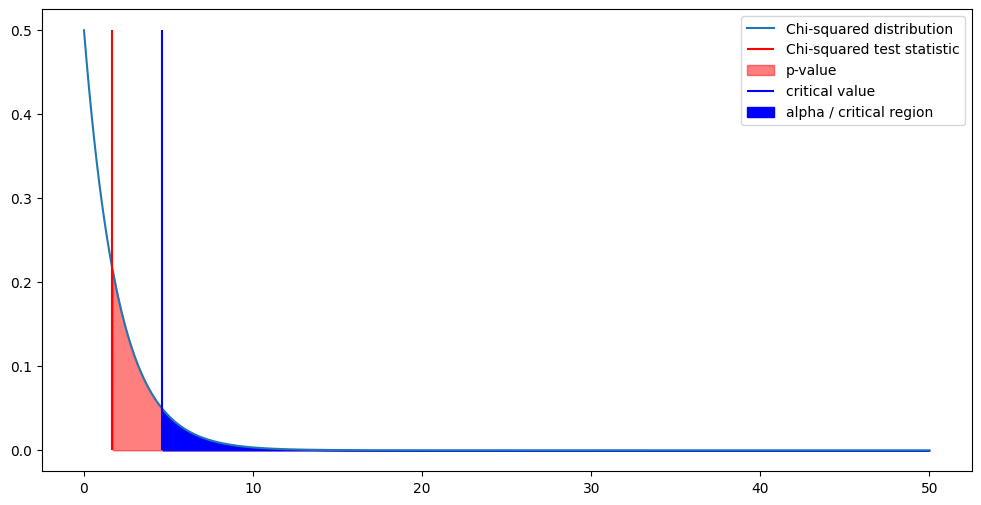

In [117]:
"""
We intentionally placed this code within a form to ensure you stayed focused
on the main topic. However, if you’re interested in exploring Matplotlib further,
you can ask ChatGPT to explain the code line by line, ensuring you understand
everything being used here. There are also plenty of free courses and YouTube
videos available on Matplotlib.

Our suggestion, though, is not to attempt to learn everything about Matplotlib
in one go — you’ll likely forget most of it and end up googling for answers like
the rest of us. Instead, adopt a curious mindset. When you encounter Matplotlib
code, take the time to examine and understand it, but don’t linger. Over time,
this approach helps you gradually discover what’s possible with Matplotlib and
develop your intuition.
"""

# @title Chi-squared distribution, test statistic, critical value and alpha
plt.figure(figsize=(12, 6))
# Plot a chi-squared distribution with the degrees of freedom from our sample.
plt.plot(xt, chi2.pdf(xt, dof), label="Chi-squared distribution")
# Add a vertical line for the chi-squared test statistic.
plt.vlines(
    chi_squared,
    ymin=0,
    ymax=max(chi2.pdf(xt, dof)),
    color="red",
    label="Chi-squared test statistic",
)
# Shade the region in the tails that is more extreme than the test statistic (= p-value).
plt.fill_between(
    xt,
    chi2.pdf(xt, dof),
    where=(xt > chi_squared),
    color="r",
    alpha=0.5,
    label="p-value",
)
# Add vertical line for the critical value.
plt.vlines(
    critical_value,
    ymin=0,
    ymax=max(chi2.pdf(xt, dof)),
    color="blue",
    label="critical value",
)
# Shade the area under the curve for values more extreme than 4.6 (= alpha).
plt.fill_between(
    xt,
    chi2.pdf(xt, dof),
    where=(xt > critical_value),
    color="b",
    label="alpha / critical region",
)
plt.legend()
plt.show()

### Using SciPy

In [118]:
chisq, pvalue, df, expected = chi2_contingency(observed_results)

In [119]:
chisq

np.float64(1.6659394708658917)

In [120]:
pvalue

np.float64(0.4347562562343731)

In [121]:
df

2

In [122]:
expected

array([[ 11.33333333,  11.33333333,  11.33333333],
       [988.66666667, 988.66666667, 988.66666667]])

Check whether the chi-squared test statistic calculated manually and the one calculated using scipy are the same.

In [123]:
chi_squared == chisq

np.False_

SUCCESS!

In [124]:
if pvalue > alpha:
    print("The p-value is larger than alpha.")
else:
    print("The p-value is smaller than alpha.")

The p-value is larger than alpha.


Does this mean that we should reject the Null Hypothesis - or not?

Since the p-value is (much) larger than alpha, we do not reject the Null Hypothesis.

# III.&nbsp;Exercise

You have tested 4 versions A, B, C and D of the "SHOP NOW" button on Eniac's website.

After the experiment is complete with 1500 visits each, these are the results:

- Version A: 134 clicks, 1500 visits.
- Version B: 102 clicks, 1500 visits.
- Version C: 78 clicks, 1500 visits.
- Version D: 129 clicks, 1500 visits.

##Exercise solution

Follow these steps:
1. State the Null and the Alternative Hypotheses.
2. Define your alpha.
3. Collect data that is random and independent
4. Calculate the test result
5. Interpret the test result

### 1.&nbsp; State the Null and the Alternative Hypotheses.

\# What hypotheses can you make?

Ho = Version A, B, C and D are of no difference.
Ha = Version A, B, C and D are different.

### 2.&nbsp;Define your alpha.

In [125]:
#let us take alpha as 0.05
alpha = 0.05

### 3.&nbsp; Collect data that is random and independent

In [126]:
Clicks = [134, 102, 78, 129]
No_click = [(1500-134), (1500-102), (1500-78),(1500-129)]
# alternative
#No_click = [1500 - x for x in Clicks]

observed_result = pd.DataFrame([Clicks, No_click], columns=["A", "B", "C","D"], index=["Click", "No-click"])
observed_result

,A,B,C,D
Click,134,102,78,129
No-click,1366,1398,1422,1371


In [127]:
chisq, pvalue ,df, expected = chi2_contingency(observed_result, correction = False)

In [128]:
chisq

np.float64(19.720109791770167)

In [129]:
pvalue

np.float64(0.00019398896739266587)

In [130]:
df

3

In [131]:
expected

array([[ 110.75,  110.75,  110.75,  110.75],
       [1389.25, 1389.25, 1389.25, 1389.25]])

### 4.&nbsp; Calculate the test result.

In [132]:
pvalue, alpha

(np.float64(0.00019398896739266587), 0.05)

### 5.&nbsp; Interpret the test result.

In [133]:
if pvalue < alpha:
  print("We reject the null hypothesis")
else:
  print("We fail to reject the null hypothesis")

We reject the null hypothesis


Since the p-value is smaller than alpha, we will reject the Null Hypothesis. Therefore, the four versions have not performed equally well.

But which version is the best one?

Let's decide to look at the click-through rates of the different versions. They might help us to declare a winner.

In [134]:
# calculate the click through rate for each version
ctr_a = observed_result.loc["Click", "A"] / sum(observed_result["A"])
ctr_b = observed_result.loc["Click", "B"] / sum(observed_result["B"])
ctr_c = observed_result.loc["Click", "C"] / sum(observed_result["C"])
ctr_d = observed_result.loc["Click", "D"] / sum(observed_result["D"])

# create a table with all four versions and their click-through rates.
ctrs = pd.DataFrame(
    {"version": ["A", "B", "C", "D"], "CTR": [ctr_a, ctr_b, ctr_c, ctr_d]}
)

ctrs.sort_values("CTR", ascending=False)

,version,CTR
0,A,0.089333
3,D,0.086000
1,B,0.068000
2,C,0.052000


Version A exhibits a significantly higher click-through rate compared to versions B and C, whereas the difference between versions A and D is relatively minor.

Given the similarity between versions A and D, we will declare both versions as the victors.

The Eniac case study, our next notebook, will shed more light on how to declare a winner from a Chi Squared test.